In [1]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col

# Не показывать Warning
import warnings
warnings.simplefilter(action='ignore', category=Warning)

# Настройки оформления графиков
plt.rcParams['figure.figsize'] = (8.5, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

CONST_NAMES = ('const', 'Intercept')


def fmt(x, decimals=3):
    """Число с заданным числом знаков; оценка, которая округляется до нуля, — с тремя значащими цифрами."""
    if pd.isna(x):
        return ''
    text = f'{x:.{decimals}f}'
    if float(text) == 0:
        return f'{x:.3g}' if x != 0 else f'{0:.{decimals}f}'
    return text


def fmt_p(p, decimals=3):
    """P-значение: меньше 0.001 печатается как «<0.001»."""
    return '<0.001' if p < 0.001 else f'{p:.{decimals}f}'


def errors_text(res, case='nom'):
    """Название типа стандартных ошибок подгонки: 'nom' — «неробастные», 'dat' — «по неробастным …»."""
    cov_type = getattr(res, 'cov_type', 'nonrobust')
    if cov_type == 'nonrobust':
        return {'nom': 'неробастные стандартные ошибки',
                'dat': 'по неробастным стандартным ошибкам'}[case]
    return {'nom': f'робастные стандартные ошибки, {cov_type}',
            'dat': f'по робастным стандартным ошибкам {cov_type}'}[case]


def fit_ols(formula, data, robust=False, **kwargs):
    """МНК-подгонка; robust=True — робастные ошибки HC3. Всегда t- и F-распределения (use_t=True)."""
    cov_type = 'HC3' if robust else 'nonrobust'
    return ols(formula, data=data).fit(cov_type=cov_type, use_t=True, **kwargs)


def show_table(df, index=True, align=None):
    """Таблица pandas в Markdown; числа должны быть заранее превращены в строки через fmt."""
    display(Markdown('\n\n' + df.to_markdown(index=index, colalign=align, disable_numparse=True) + '\n\n'))


def nobs_text(res):
    """Строка «Модель была подогнана по N наблюдениям»."""
    n = int(res.nobs)
    word = 'наблюдению' if n % 10 == 1 and n % 100 != 11 else 'наблюдениям'
    return f'Модель была подогнана по {n} {word}.'


def show_coefs(res, decimals=3, show_nobs=True):
    """Оценки коэффициентов: вертикальная таблица «Переменная | Оценка» и число наблюдений."""
    cov_type = getattr(res, 'cov_type', 'nonrobust')
    column = 'Оценка' if cov_type == 'nonrobust' else f'Оценка ({cov_type})'
    table = pd.DataFrame({'Переменная': res.params.index,
                          column: [fmt(b, decimals) for b in res.params]})
    text = table.to_markdown(index=False, colalign=('left', 'right'), disable_numparse=True)
    if show_nobs:
        text += '\n\n' + nobs_text(res)
    display(Markdown('\n\n' + text + '\n\n'))


def display_answer(text, use_callout=True, theme='note', title='Критическое значение'):
    """Ответ в рамке (callout): theme='note' — число, 'tip' — вывод, 'important' — условие."""
    if use_callout:
        head = f'title="{title}" ' if title else ''
        output_md = f'\n\n::: {{.callout-{theme} {head}icon="true"}}\n{text}\n:::\n\n'
    elif title:
        output_md = f'\n\n**{title}:** {text}\n\n'
    else:
        output_md = f'\n\n{text}\n\n'
    display(Markdown(output_md))


def show_conditions(level, errors=None, hypothesis=None, extra=()):
    """Блок «Условия теста»: уровень значимости (доля или список долей), тип ошибок, гипотеза формулой."""
    levels = level if isinstance(level, (list, tuple)) else [level]
    items = ['уровень значимости: **' + ' и '.join(f'{a * 100:g}%' for a in levels) + '**']
    if errors:
        items.append(f'стандартные ошибки: **{errors}**')
    hypotheses = [hypothesis] if isinstance(hypothesis, str) else list(hypothesis or [])
    if len(hypotheses) == 1:
        items.append(f'гипотеза: {hypotheses[0]}')
    else:
        items += [f'гипотеза {i}: {h}' for i, h in enumerate(hypotheses, start=1)]
    items += list(extra)
    display_answer('\n'.join(f'- {item}' for item in items), theme='important', title='Условия теста')


def signif_stars(p):
    """Коды значимости: *** p<0.01, ** p<0.05, * p<0.1."""
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


SIGNIF_LEGEND = '*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$'


def print_regression_summary(res, decimals=3, show_signif=True):
    """Таблица t-теста: Coef., Std.Err., t-value, p-value, Signif. Заголовок называет тип ошибок."""
    title = f'**Результаты $t$-теста для коэффициентов ({errors_text(res)}):**'
    table = pd.DataFrame({
        'Coef.': [fmt(b, decimals) for b in res.params],
        'Std.Err.': [fmt(s, decimals) for s in res.bse],
        't-value': [fmt(t, decimals) for t in res.tvalues],
        'p-value': [fmt_p(p, decimals) for p in res.pvalues],
    }, index=res.params.index)
    legend = ''
    if show_signif:
        table['Signif.'] = ['' if name in CONST_NAMES else signif_stars(p)
                            for name, p in res.pvalues.items()]
        legend = '\n\n' + SIGNIF_LEGEND
    align = ('left',) + ('right',) * 4 + (('left',) if show_signif else ())
    display(Markdown(f'\n\n{title}\n\n' + table.to_markdown(colalign=align, disable_numparse=True) + legend + '\n\n'))


def print_significant_coeffs(res, sign_level=0.05, theme='note', title=None):
    """Рамка со списком коэффициентов, значимых на уровне sign_level (без константы)."""
    names = [name for name, p in res.pvalues.items() if p < sign_level and name not in CONST_NAMES]
    if title is None:
        title = f'Коэффициенты, значимые на уровне {sign_level * 100:g}% ({errors_text(res, "dat")})'
    text = ', '.join(f'`{name}`' for name in names) if names else 'Значимых коэффициентов не выявлено.'
    display_answer(text, theme=theme, title=title)


def show_models(models, names=None, decimals=3, regressor_order=(), errors_note=None, info=None):
    """Сравнение регрессий (summary_col): строка Dep. Variable, коды значимости, пояснение про скобки.

    info — словарь {название строки: функция от подгонки} для дополнительных строк (N, F и т. п.).
    """
    table = summary_col(models, model_names=names, stars=True, float_format=f'%0.{decimals}f',
                        regressor_order=list(regressor_order), info_dict=info or {}).tables[0]
    top = pd.DataFrame({col: [m.model.endog_names] for col, m in zip(table.columns, models)},
                       index=['Dep. Variable'])
    table = pd.concat([top, table])
    if errors_note is None:
        errors_note = errors_text(models[0])
    note = f'{SIGNIF_LEGEND}. В скобках — {errors_note}.'
    display(Markdown('\n\n' + table.to_markdown(disable_numparse=True) + '\n\n' + note + '\n\n'))


def show_ci(res, level=0.95, decimals=3):
    """Доверительные интервалы: «Переменная | Нижняя граница | Верхняя граница», заголовок над таблицей."""
    ci = res.conf_int(alpha=1 - level)
    table = pd.DataFrame({'Переменная': ci.index,
                          'Нижняя граница': [fmt(x, decimals) for x in ci[0]],
                          'Верхняя граница': [fmt(x, decimals) for x in ci[1]]})
    title = f'**{level * 100:g}%-е доверительные интервалы ({errors_text(res)}):**'
    display(Markdown(f'\n\n{title}\n\n'
                     + table.to_markdown(index=False, colalign=('left', 'right', 'right'), disable_numparse=True) + '\n\n'))


# Загрузка данных
sleep75 = pd.read_csv('../datasets/sleep75.csv')
Labour = pd.read_csv('../datasets/Labour.csv')

my_digits = 2


def show_estimates(formula, data, decimals=my_digits):
    """Оценки МНК-подгонки в виде show_coefs, но числа печатаются как есть.

    В show_coefs tabulate заново разбирает строки-числа и теряет нули в конце (0.30 -> 0.3).
    """
    res = fit_ols(formula, data)
    table = pd.DataFrame({'Переменная': res.params.index,
                          'Оценка': [fmt(b, decimals) for b in res.params]})
    text = table.to_markdown(index=False, colalign=('left', 'right'), disable_numparse=True)
    display(Markdown('\n\n' + text + '\n\n' + nobs_text(res) + '\n\n'))


def plot_fit(data, y, x, fits, log=False):
    """Диаграмма рассеяния y от x (log=True — в логарифмах) с подогнанными линиями.

    fits — список пар (формула, подпись в легенде); первая линия сплошная, вторая штриховая.
    """
    scale = np.log if log else (lambda v: v)
    name = (lambda v: f'np.log({v})') if log else (lambda v: v)
    grid = np.linspace(scale(data[x]).min(), scale(data[x]).max(), 200)
    new = pd.DataFrame({x: np.exp(grid) if log else grid})
    fig, ax = plt.subplots()
    ax.scatter(scale(data[x]), scale(data[y]), s=12, alpha=0.4, color='tab:blue', label='наблюдения')
    for (formula, label), style, color in zip(fits, ['-', '--'], ['tab:red', 'black']):
        ax.plot(grid, fit_ols(formula, data).predict(new), style, color=color, linewidth=2, label=label)
    ax.set_xlabel(name(x))
    ax.set_ylabel(name(y))
    ax.legend()
    plt.show()

# Теория

## Задача (прямая с константой)

Пусть задано $n$ наблюдений (точек на плоскости) $\lbrace x_i,y_i\rbrace_{i=1}^n$.
Линейная функция $y=\beta_0+\beta_1x$ «подгоняется» под наблюдения методом наименьших квадратов (OLS):

- выведите систему уравнений для нахождения параметров оптимальной (подогнанной) прямой, наименее уклоняющейся от заданных наблюдений;
- выведите формулы для оценок $\widehat{\beta}_0$ и $\widehat{\beta}_1$ коэффициентов оптимальной прямой;
- покажите, что для оценок коэффициентов верно:

$$
\begin{aligned}
  \widehat{\beta}_1&=\frac{\mathrm{s.cov}(x,y)}{\mathrm{s.Var}(x)}, &
  \widehat{\beta}_0&=\bar{y}-\widehat{\beta}_1\cdot \bar{x}.
\end{aligned}
$$

Здесь $\mathrm{s.cov}(x,y)$ — выборочная ковариация, $\mathrm{s.Var}(x)$ — выборочная дисперсия.

## Задача (прямая без константы)

Пусть задано $n$ наблюдений (точек на плоскости) $\lbrace x_i,y_i\rbrace_{i=1}^n$.
Линейная функция $y=\beta x$ подгоняется под наблюдения методом наименьших квадратов (OLS):

- выведите уравнение для нахождения параметра оптимальной прямой, наименее уклоняющейся от заданных наблюдений (точек на плоскости);
- выведите формулу для оценки $\widehat{\beta}$ коэффициента оптимальной прямой.

## Задача (обратная регрессия без константы)

Пусть $\widehat{\beta}$ есть OLS-оценка коэффициента наклона линейной
функции $y$ на $x$ без константы, а $\widehat{\gamma}$ — OLS-оценка
коэффициента наклона линейной функции $x$ на $y$ без константы.
Верно ли для этих оценок равенство

$$
\widehat{\gamma}=\frac{1}{\widehat{\beta}}?
$$

Ответ поясните.

## Задача (обратная регрессия с константой)

Пусть $\widehat{\beta}_1$ есть OLS-оценка коэффициента наклона линейной
функции $y$ на $x$ с константой, а $\widehat{\gamma}_1$ — OLS-оценка коэффициента наклона линейной
функции $x$ на $y$ с константой. Верно ли равенство

$$
\widehat{\gamma}_1=\frac{1}{\widehat{\beta}_1}?
$$

Ответ поясните.

## Задача (квадратичный многочлен)

Пусть задано $n$ наблюдений (точек на плоскости) $\lbrace x_i,y_i\rbrace_{i=1}^n$.
Парабола $y=\beta_0+\beta_1x+\beta_2x^2$ подгоняется под наблюдения методом наименьших квадратов (OLS).
Выведите систему уравнений для нахождения параметров оптимальной параболы.

# Практика (Python)

::: {.callout-important title="Важно"}
- Во всех задачах логарифм натуральный; константа включается по умолчанию.
- Данные — в папке `datasets/`, описание наборов данных — в файле [`datasets/data-description.md`](../datasets/data-description.md).
- Численные ответы округлите до 2-х десятичных знаков; оценки, которые при этом обращаются в ноль, — до трёх значащих цифр.
- В ответах коэффициенты подписаны так, как их выводит statsmodels: `Intercept` — константа, `np.log(x)` — $\log x$, `I(x ** 2)` — $x^2$.
:::

## sleep equation #1

Для набора данных `sleep75` (`sleep`, `totwrk` — минуты в неделю, `age` — годы) рассмотрим регрессию **sleep на totwrk**.

Постройте диаграмму рассеяния **sleep vs totwrk** с подогнанной прямой.

Ответ: @fig-sleep-totwrk; на нём показаны обе прямые — с константой и без константы.

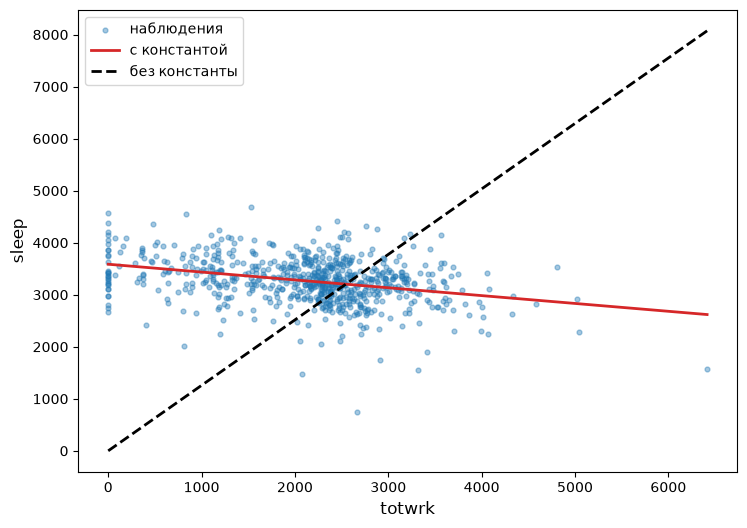

In [2]:
#| label: fig-sleep-totwrk
#| fig-cap: "sleep и totwrk: подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(sleep75, 'sleep', 'totwrk',
         [('sleep ~ totwrk', 'с константой'), ('sleep ~ 0 + totwrk', 'без константы')])

**С константой**

Найдите параметры оптимальной прямой **sleep на totwrk**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [3]:
#| output: asis
show_estimates('sleep ~ totwrk', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |  3586.38 |
| totwrk       |    -0.15 |

Модель была подогнана по 706 наблюдениям.



**Без константы**

Найдите параметры оптимальной прямой **sleep на totwrk** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [4]:
#| output: asis
show_estimates('sleep ~ 0 + totwrk', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| totwrk       |     1.26 |

Модель была подогнана по 706 наблюдениям.



## sleep equation #2

Для набора данных `sleep75` рассмотрим регрессию **sleep на age**.

Постройте диаграмму рассеяния **sleep vs age** с подогнанной прямой.

Ответ: @fig-sleep-age; на нём показаны обе прямые — с константой и без константы.

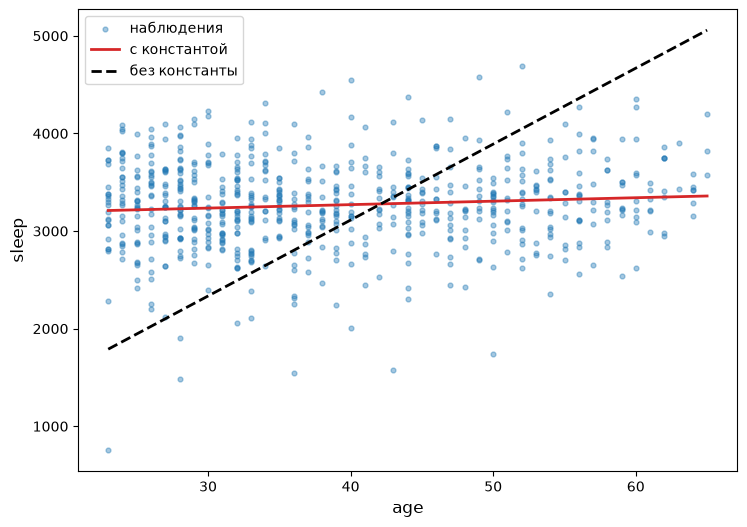

In [5]:
#| label: fig-sleep-age
#| fig-cap: "sleep и age: подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(sleep75, 'sleep', 'age',
         [('sleep ~ age', 'с константой'), ('sleep ~ 0 + age', 'без константы')])

**С константой**

Найдите параметры оптимальной прямой **sleep на age**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [6]:
#| output: asis
show_estimates('sleep ~ age', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |  3128.91 |
| age          |     3.54 |

Модель была подогнана по 706 наблюдениям.



**Без константы**

Найдите параметры оптимальной прямой **sleep на age** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [7]:
#| output: asis
show_estimates('sleep ~ 0 + age', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| age          |    77.82 |

Модель была подогнана по 706 наблюдениям.



## sleep equation #3

Для набора данных `sleep75` рассмотрим регрессию **sleep на totwrk, I(totwrk\*\*2)**.

Постройте диаграмму рассеяния **sleep vs totwrk** с подогнанной параболой.

Ответ: @fig-sleep-totwrk-sq.

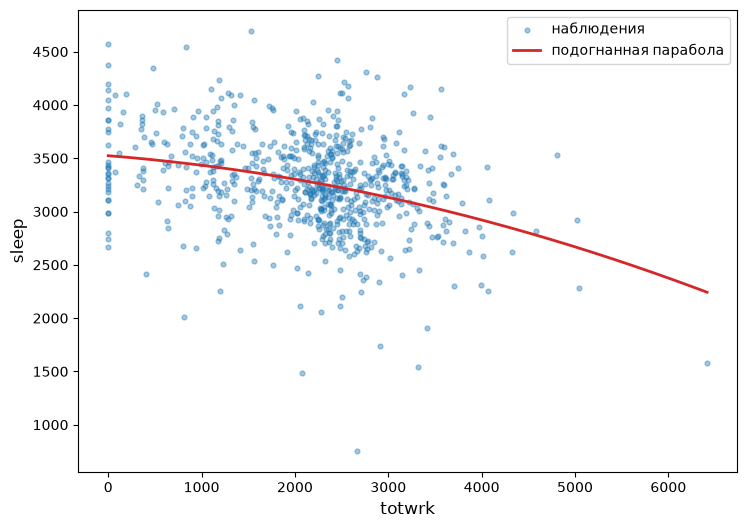

In [8]:
#| label: fig-sleep-totwrk-sq
#| fig-cap: "sleep и totwrk: подогнанная парабола"
#| fig-align: "center"
plot_fit(sleep75, 'sleep', 'totwrk', [('sleep ~ totwrk + I(totwrk**2)', 'подогнанная парабола')])

Найдите параметры оптимальной параболы **sleep на totwrk, I(totwrk\*\*2)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [9]:
#| output: asis
show_estimates('sleep ~ totwrk + I(totwrk**2)', sleep75)



| Переменная     |    Оценка |
|:---------------|----------:|
| Intercept      |   3523.59 |
| totwrk         |     -0.07 |
| I(totwrk ** 2) | -2.03e-05 |

Модель была подогнана по 706 наблюдениям.



## sleep equation #4

Для набора данных `sleep75` рассмотрим регрессию **sleep на age, I(age\*\*2)**.

Постройте диаграмму рассеяния **sleep vs age** с подогнанной параболой.

Ответ: @fig-sleep-age-sq.

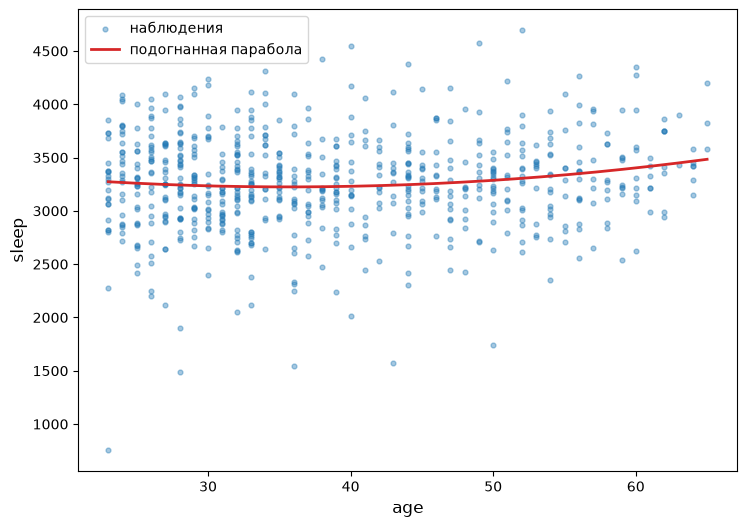

In [10]:
#| label: fig-sleep-age-sq
#| fig-cap: "sleep и age: подогнанная парабола"
#| fig-align: "center"
plot_fit(sleep75, 'sleep', 'age', [('sleep ~ age + I(age**2)', 'подогнанная парабола')])

Найдите параметры оптимальной параболы **sleep на age, I(age\*\*2)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [11]:
#| output: asis
show_estimates('sleep ~ age + I(age**2)', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |  3608.03 |
| age          |   -21.49 |
| I(age ** 2)  |     0.30 |

Модель была подогнана по 706 наблюдениям.



## sleep equation #5

Для набора данных `sleep75` рассмотрим регрессию **sleep на totwrk, age**.

Найдите параметры оптимальной плоскости **sleep на totwrk, age**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [12]:
#| output: asis
show_estimates('sleep ~ totwrk + age', sleep75)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |  3469.20 |
| totwrk       |    -0.15 |
| age          |     2.92 |

Модель была подогнана по 706 наблюдениям.



## output equation #1

Для набора данных `Labour` (`output`, `capital` — млн евро, `labour` — число работников) рассмотрим регрессии **output на capital** и **np.log(output) на np.log(capital)**.

**Гистограммы**

Постройте гистограммы переменных **output, np.log(output), capital, np.log(capital), labour, np.log(labour)**.

Ответ: @fig-labour-hist.

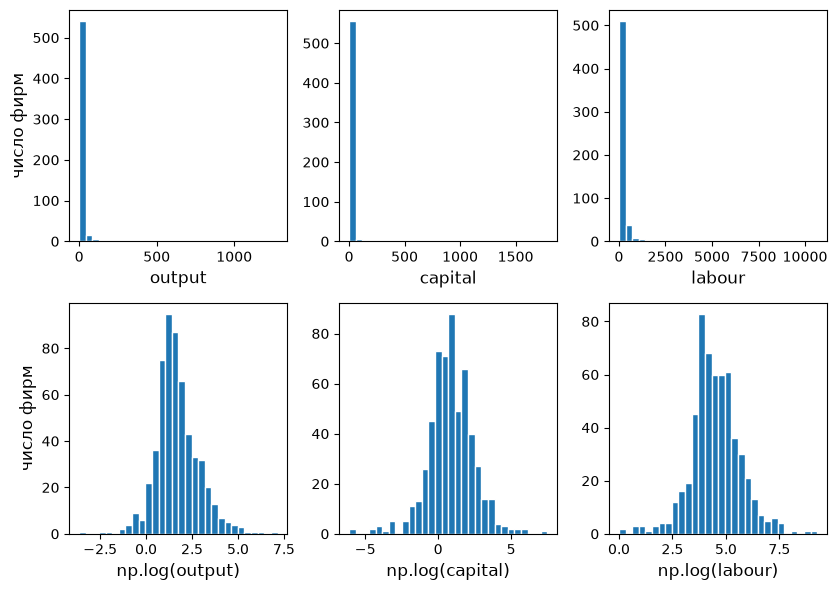

In [13]:
#| label: fig-labour-hist
#| fig-cap: "Гистограммы output, capital, labour и их логарифмов (Labour)"
#| fig-align: "center"
fig, axes = plt.subplots(2, 3)
for j, var in enumerate(['output', 'capital', 'labour']):
    axes[0, j].hist(Labour[var], bins=30, color='tab:blue', edgecolor='white')
    axes[0, j].set_xlabel(var)
    axes[1, j].hist(np.log(Labour[var]), bins=30, color='tab:blue', edgecolor='white')
    axes[1, j].set_xlabel(f'np.log({var})')
for ax in axes[:, 0]:
    ax.set_ylabel('число фирм')
fig.tight_layout()
plt.show()

**Диаграмма рассеяния**

Постройте диаграмму рассеяния **output vs capital** с подогнанной прямой.

Ответ: @fig-output-capital; на нём показаны обе прямые — с константой и без константы.

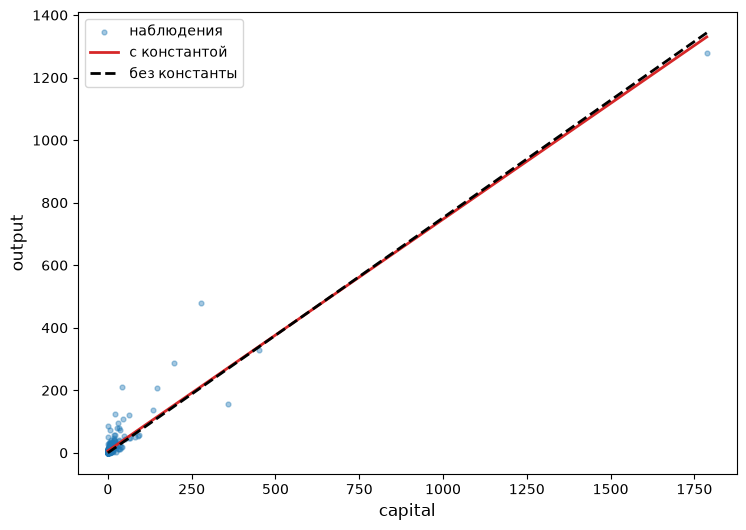

In [14]:
#| label: fig-output-capital
#| fig-cap: "output и capital: подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(Labour, 'output', 'capital',
         [('output ~ capital', 'с константой'), ('output ~ 0 + capital', 'без константы')])

**С константой**

Найдите параметры оптимальной прямой **output на capital**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [15]:
#| output: asis
show_estimates('output ~ capital', Labour)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |     6.19 |
| capital      |     0.74 |

Модель была подогнана по 569 наблюдениям.



**Без константы**

Найдите параметры оптимальной прямой **output на capital** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [16]:
#| output: asis
show_estimates('output ~ 0 + capital', Labour)



| Переменная   |   Оценка |
|:-------------|---------:|
| capital      |     0.75 |

Модель была подогнана по 569 наблюдениям.



**Диаграмма рассеяния в логарифмах**

Постройте диаграмму рассеяния **np.log(output) vs np.log(capital)** с подогнанной прямой.

Ответ: @fig-output-capital-log; на нём показаны обе прямые — с константой и без константы.

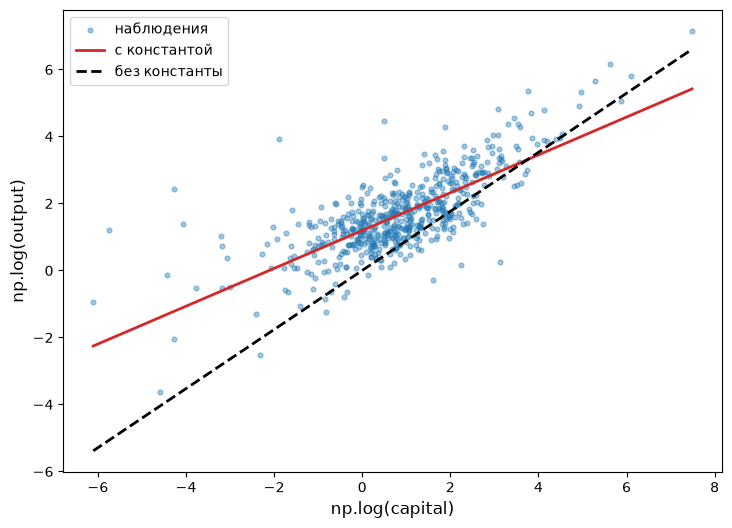

In [17]:
#| label: fig-output-capital-log
#| fig-cap: "np.log(output) и np.log(capital): подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(Labour, 'output', 'capital',
         [('np.log(output) ~ np.log(capital)', 'с константой'),
          ('np.log(output) ~ 0 + np.log(capital)', 'без константы')], log=True)

**В логарифмах, с константой**

Найдите параметры оптимальной прямой **np.log(output) на np.log(capital)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [18]:
#| output: asis
show_estimates('np.log(output) ~ np.log(capital)', Labour)



| Переменная      |   Оценка |
|:----------------|---------:|
| Intercept       |     1.19 |
| np.log(capital) |     0.56 |

Модель была подогнана по 569 наблюдениям.



**В логарифмах, без константы**

Найдите параметры оптимальной прямой **np.log(output) на np.log(capital)** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [19]:
#| output: asis
show_estimates('np.log(output) ~ 0 + np.log(capital)', Labour)



| Переменная      |   Оценка |
|:----------------|---------:|
| np.log(capital) |     0.88 |

Модель была подогнана по 569 наблюдениям.



## output equation #2

Для набора данных `Labour` рассмотрим регрессии **output на labour** и **np.log(output) на np.log(labour)**.

**Диаграмма рассеяния**

Постройте диаграмму рассеяния **output vs labour** с подогнанной прямой.

Ответ: @fig-output-labour; на нём показаны обе прямые — с константой и без константы.

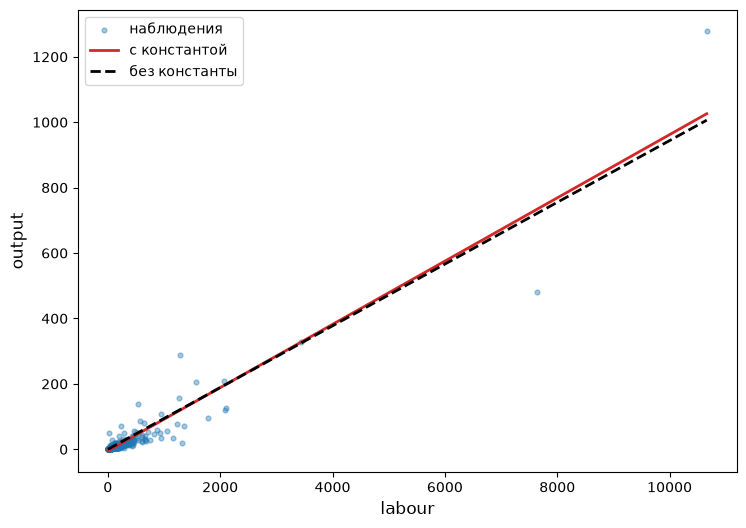

In [20]:
#| label: fig-output-labour
#| fig-cap: "output и labour: подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(Labour, 'output', 'labour',
         [('output ~ labour', 'с константой'), ('output ~ 0 + labour', 'без константы')])

**С константой**

Найдите параметры оптимальной прямой **output на labour**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [21]:
#| output: asis
show_estimates('output ~ labour', Labour)



| Переменная   |   Оценка |
|:-------------|---------:|
| Intercept    |    -4.72 |
| labour       |     0.10 |

Модель была подогнана по 569 наблюдениям.



**Без константы**

Найдите параметры оптимальной прямой **output на labour** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [22]:
#| output: asis
show_estimates('output ~ 0 + labour', Labour)



| Переменная   |   Оценка |
|:-------------|---------:|
| labour       |     0.09 |

Модель была подогнана по 569 наблюдениям.



**Диаграмма рассеяния в логарифмах**

Постройте диаграмму рассеяния **np.log(output) vs np.log(labour)** с подогнанной прямой.

Ответ: @fig-output-labour-log; на нём показаны обе прямые — с константой и без константы.

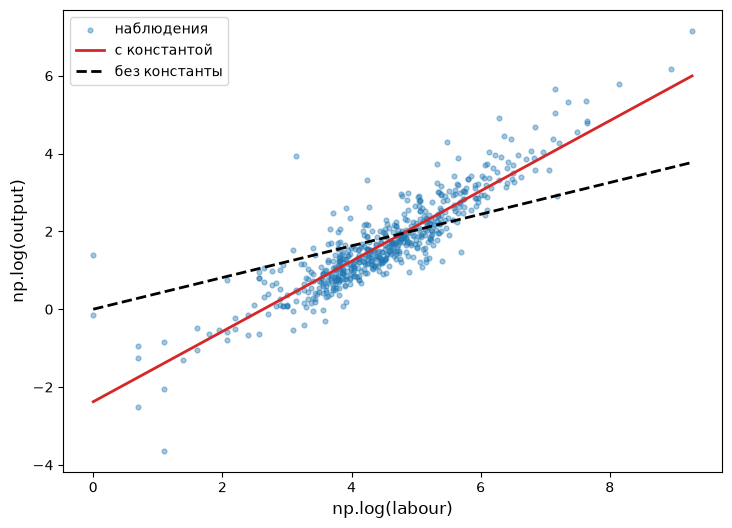

In [23]:
#| label: fig-output-labour-log
#| fig-cap: "np.log(output) и np.log(labour): подогнанные прямые с константой и без константы"
#| fig-align: "center"
plot_fit(Labour, 'output', 'labour',
         [('np.log(output) ~ np.log(labour)', 'с константой'),
          ('np.log(output) ~ 0 + np.log(labour)', 'без константы')], log=True)

**В логарифмах, с константой**

Найдите параметры оптимальной прямой **np.log(output) на np.log(labour)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [24]:
#| output: asis
show_estimates('np.log(output) ~ np.log(labour)', Labour)



| Переменная     |   Оценка |
|:---------------|---------:|
| Intercept      |    -2.38 |
| np.log(labour) |     0.90 |

Модель была подогнана по 569 наблюдениям.



**В логарифмах, без константы**

Найдите параметры оптимальной прямой **np.log(output) на np.log(labour)** без константы.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [25]:
#| output: asis
show_estimates('np.log(output) ~ 0 + np.log(labour)', Labour)



| Переменная     |   Оценка |
|:---------------|---------:|
| np.log(labour) |     0.41 |

Модель была подогнана по 569 наблюдениям.



## output equation #3

Для набора данных `Labour` рассмотрим регрессию **np.log(output) на np.log(capital), I(np.log(capital)\*\*2)**.

Постройте диаграмму рассеяния **np.log(output) vs np.log(capital)** с подогнанной параболой.

Ответ: @fig-output-capital-sq.

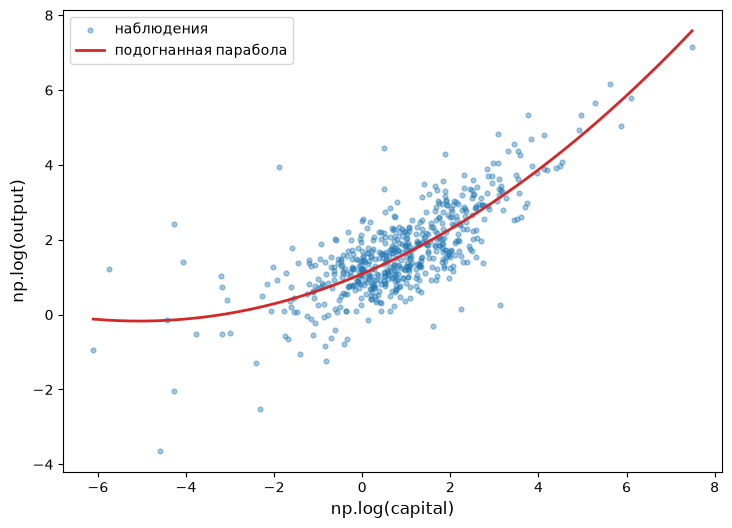

In [26]:
#| label: fig-output-capital-sq
#| fig-cap: "np.log(output) и np.log(capital): подогнанная парабола"
#| fig-align: "center"
plot_fit(Labour, 'output', 'capital',
         [('np.log(output) ~ np.log(capital) + I(np.log(capital)**2)', 'подогнанная парабола')],
         log=True)

Найдите параметры оптимальной параболы **np.log(output) на np.log(capital), I(np.log(capital)\*\*2)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [27]:
#| output: asis
show_estimates('np.log(output) ~ np.log(capital) + I(np.log(capital)**2)', Labour)



| Переменная              |   Оценка |
|:------------------------|---------:|
| Intercept               |     1.09 |
| np.log(capital)         |     0.50 |
| I(np.log(capital) ** 2) |     0.05 |

Модель была подогнана по 569 наблюдениям.



## output equation #4

Для набора данных `Labour` рассмотрим регрессию **np.log(output) на np.log(labour), I(np.log(labour)\*\*2)**.

Постройте диаграмму рассеяния **np.log(output) vs np.log(labour)** с подогнанной параболой.

Ответ: @fig-output-labour-sq.

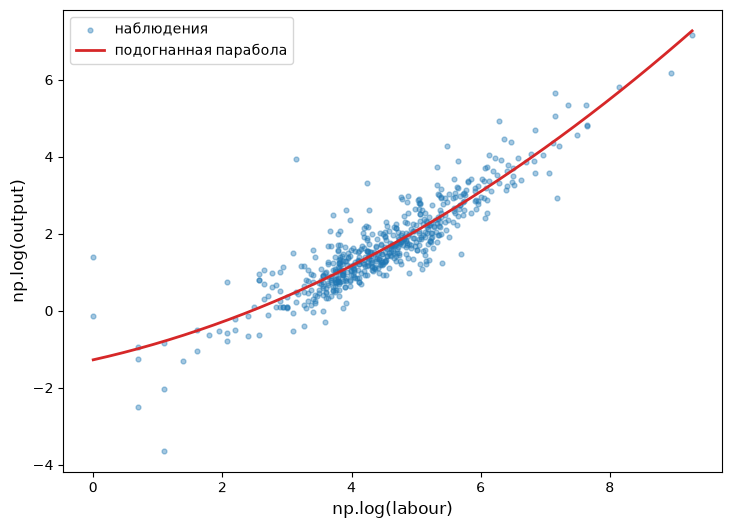

In [28]:
#| label: fig-output-labour-sq
#| fig-cap: "np.log(output) и np.log(labour): подогнанная парабола"
#| fig-align: "center"
plot_fit(Labour, 'output', 'labour',
         [('np.log(output) ~ np.log(labour) + I(np.log(labour)**2)', 'подогнанная парабола')],
         log=True)

Найдите параметры оптимальной параболы **np.log(output) на np.log(labour), I(np.log(labour)\*\*2)**.
**Ответ округлите до 2-х десятичных знаков.**

Ответ:

In [29]:
#| output: asis
show_estimates('np.log(output) ~ np.log(labour) + I(np.log(labour)**2)', Labour)



| Переменная             |   Оценка |
|:-----------------------|---------:|
| Intercept              |    -1.28 |
| np.log(labour)         |     0.37 |
| I(np.log(labour) ** 2) |     0.06 |

Модель была подогнана по 569 наблюдениям.

